In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pydot

# Evaluation libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [2]:
fashion_train = pd.read_csv("fashion-mnist_train.csv")
fashion_test = pd.read_csv("fashion-mnist_test.csv")

In [3]:
fashion_train.shape

(60000, 785)

In [4]:
X_train_fashion = fashion_train.drop('label', axis=1)
y_train_fashion = fashion_train['label']
X_test_fashion = fashion_test.drop('label', axis=1)
y_test_fashion = fashion_test['label']

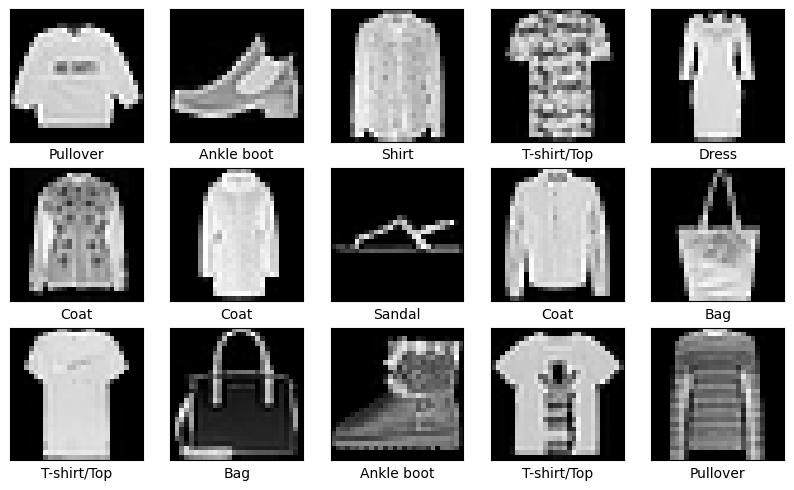

In [5]:
# Reshaping the dataset
X_train_reshape = X_train_fashion.values.reshape(-1,28,28)
X_test_reshape = X_test_fashion.values.reshape(-1,28,28)

# Names of numbers in the dataset in order
col_names = ["T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

#visualizing the digits
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_reshape[i], cmap='gray')
    plt.xlabel(col_names[y_train_fashion[i]])
plt.show()

In [6]:
# Encoding Output
y_train_fashion = to_categorical(y_train_fashion, num_classes = 10)
y_test_fashion = to_categorical(y_test_fashion, num_classes = 10)

In [7]:
y_train_fashion[1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [8]:
#creating base neural network
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(10, activation='softmax')
])

C:\Users\Raji\anaconda3\envs\aiml\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# param = number of output channel * (number of input channel + 1)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24)                  │           3,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             250 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 105,130 (410.66 KB)

 Trainable params: 104,778 (409.29 KB)

 Non-trainable params: 352 (1.38 KB)

In [10]:
# compiling - Prepare the model for training by defining: error calculation, learning method, evaluation metric
model.compile(loss = "categorical_crossentropy",
              optimizer = "adam",
              metrics =["accuracy"])

In [11]:
history = model.fit(X_train_fashion, y_train_fashion, batch_size = 100, epochs=15, validation_data = (X_test_fashion, y_test_fashion))

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6105 - loss: 1.1295 - val_accuracy: 0.8032 - val_loss: 0.5481
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7439 - loss: 0.7557 - val_accuracy: 0.8459 - val_loss: 0.4815
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7702 - loss: 0.6762 - val_accuracy: 0.8406 - val_loss: 0.4610
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7901 - loss: 0.6312 - val_accuracy: 0.8465 - val_loss: 0.4551
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7959 - loss: 0.6139 - val_accuracy: 0.8532 - val_loss: 0.4269
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7996 - loss: 0.6028 - val_accuracy: 0.8488 - val_loss: 0.4459
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8052 - loss: 0.5854 - val_accuracy: 0.8577 - val_loss: 0.4239
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8071 - loss: 0.5804 - val_accuracy: 0.

In [12]:
y_predict = model.predict(X_test_fashion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   


In [13]:
# Convert predicted probabilities into class labels
y_predicts = np.argmax(y_predict, axis=1)
# Convert one-hot encoded test labels into actual digit labels
y_test_fashion_eval = np.argmax(y_test_fashion, axis=1)

In [14]:
y_test_fashion_eval

array([0, 1, 2, ..., 8, 8, 1], dtype=int64)

In [15]:
y_predicts

array([0, 1, 2, ..., 8, 8, 1], dtype=int64)

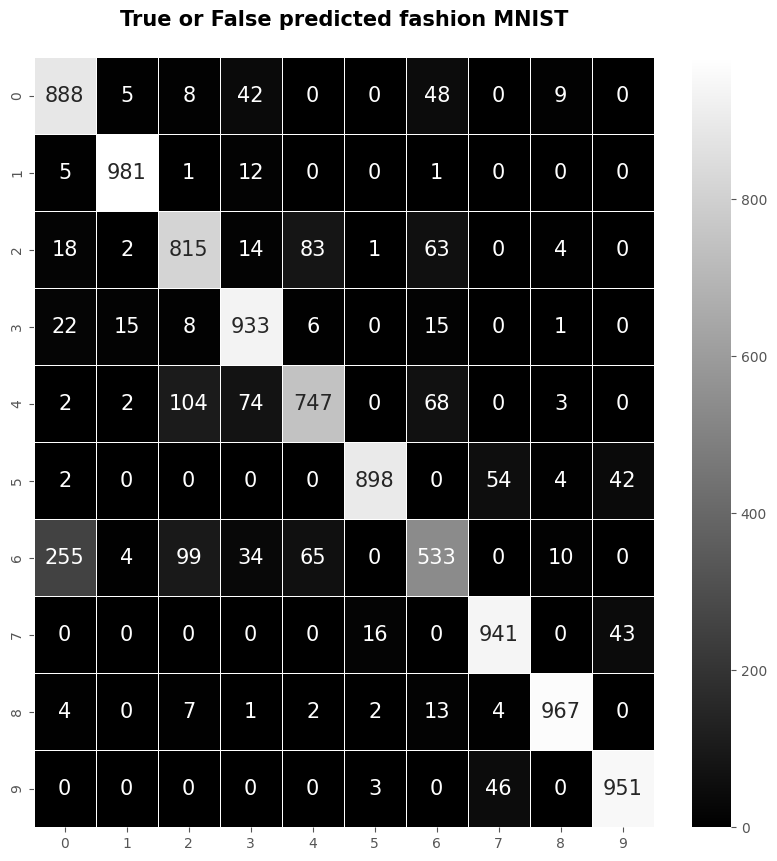

In [16]:
# Create confusion matrix using actual and predicted labels
con_mat = confusion_matrix(y_test_fashion_eval, y_predicts)
plt.style.use("ggplot")
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot=True, annot_kws={'size': 15}, linewidths=0.5, fmt="d", cmap ="gray")
plt.title("True or False predicted fashion MNIST\n", fontweight='bold', fontsize=15)
plt.show()

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test_fashion_eval, y_predicts))

              precision    recall  f1-score   support

           0       0.74      0.89      0.81      1000
           1       0.97      0.98      0.98      1000
           2       0.78      0.81      0.80      1000
           3       0.84      0.93      0.88      1000
           4       0.83      0.75      0.79      1000
           5       0.98      0.90      0.94      1000
           6       0.72      0.53      0.61      1000
           7       0.90      0.94      0.92      1000
           8       0.97      0.97      0.97      1000
           9       0.92      0.95      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.86      0.87      0.86     10000
weighted avg       0.86      0.87      0.86     10000



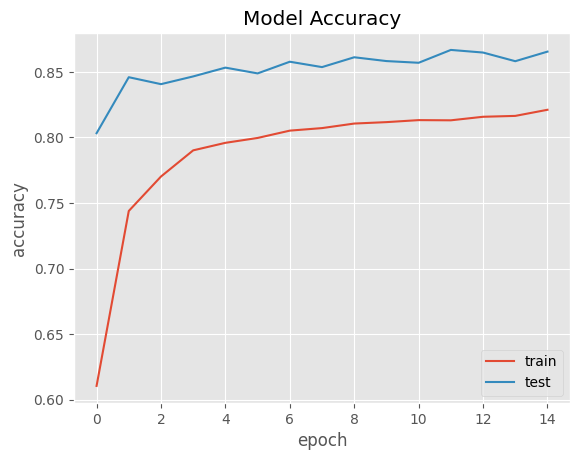

In [18]:
# graph for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

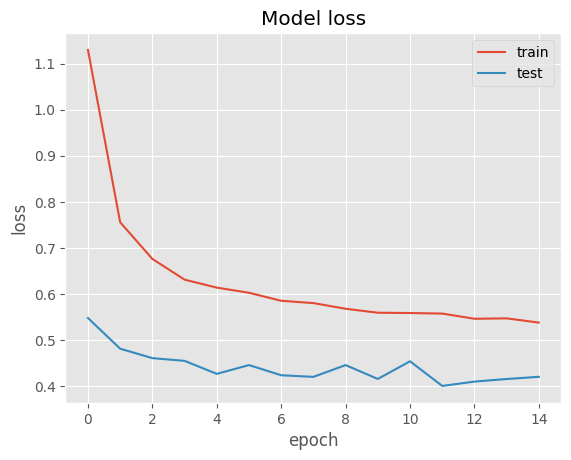

In [19]:
# graph for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [20]:
y_predict_single = model.predict(X_test_fashion.loc[[2],:].values)
y_predicts_single = np.argmax(y_predict_single, axis=1)
y_test_fashion_eval = np.argmax(y_test_fashion, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


In [21]:
y_predict_single

array([[9.0805441e-03, 3.8209031e-04, 6.2317455e-01, 1.6982155e-03,
        6.9047049e-02, 4.4200924e-04, 2.9356530e-01, 1.5279275e-04,
        2.4351801e-03, 2.2317361e-05]], dtype=float32)

In [22]:
y_predicts_single

array([2], dtype=int64)

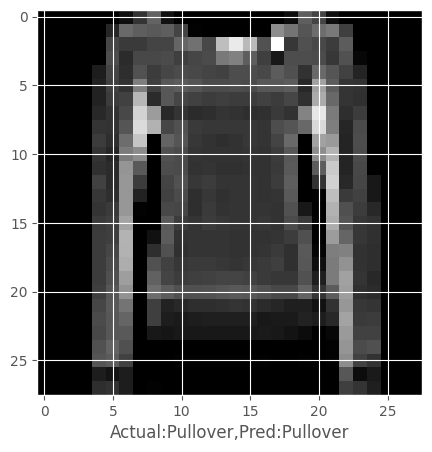

In [23]:
col_names = ["T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(5,5))
plt.imshow(X_test_reshape[2], cmap='gray',interpolation='nearest')

plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_fashion[2])],col_names[y_predicts_single[0]]))
plt.show()